In [1]:
%matplotlib inline

import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import time

from utils.configure import Configure
import mmwave_processing.dsp as dsp
from mmwave_processing.dsp.utils import Window, windowing
from mmwave_processing.dsp.compensation import exponential_smoothing

In [2]:
#style = 'free_style'
#style = 'stipulated'
style = 'mixed'

In [3]:
raw_dir = 'data/raw_data'
target_dir = 'data/training_data_v3_'+style
verify_dir = 'data/training_data_v2_mixed'
#verify_dir = 'data/training_data'
exception_folder = ['character', 'nac']
configs = Configure(config_file='fmcw_radar.cfg')
BINS_for_Gesture = configs.RANGE_FFT//2    # 32
configs.frame_rate = 1 / configs.frame_repetition_time_s
NUM_FRAMES = int(configs.frame_rate*configs.win_len)
ANGLE_RES = 4
ANGLE_BINS = (configs.max_angle_degrees * 2) // ANGLE_RES + 1      # 31

In [4]:
rangeCube = np.zeros((NUM_FRAMES, configs.DOPPLER_FFT, configs.NUM_RX+1, 
                      configs.RANGE_FFT), dtype=np.complex128)    # (60, 32, 3, 64)
range_doppler = np.zeros((NUM_FRAMES, configs.RANGE_FFT//2, 
                          configs.DOPPLER_FFT), dtype=np.float64) # (60, 32, 32)
RD_Map = np.zeros((configs.RANGE_FFT//2, 
                   configs.DOPPLER_FFT), dtype=np.float64)        # (60, 32, 32)
aoa_input = np.zeros((configs.RANGE_FFT//2, configs.NUM_RX+1, 
                      configs.DOPPLER_FFT), dtype=np.complex128)  # (60, 32, 32)
num_vec, steering_vec = dsp.gen_steering_vec(configs.max_angle_degrees, ANGLE_RES, configs.NUM_RX)
range_azimuth = np.zeros((ANGLE_BINS, BINS_for_Gesture), 
                         dtype=np.float64)                        # (60, 31, 32)
range_azimuth_pad = np.zeros((1, BINS_for_Gesture), dtype=np.float64)
range_spec_img = np.zeros((NUM_FRAMES, configs.RANGE_FFT//2), dtype=np.float64)
uDoppler_img = np.zeros((NUM_FRAMES, configs.DOPPLER_FFT), dtype=np.float64)
angle_spec_img = np.zeros((NUM_FRAMES, ANGLE_BINS+1), dtype=np.float64)

In [5]:
if not os.path.isdir(target_dir):
    os.mkdir(target_dir)

In [6]:
gestures = os.listdir(raw_dir)

In [7]:
for d in gestures:
    if not os.path.isdir(os.path.join(target_dir, d)):
        os.mkdir(os.path.join(target_dir, d))

In [8]:
volunteers = os.listdir(os.path.join(raw_dir, d))

In [9]:
volunteers

['grace', 'peggy', 'joseph', 'emily', 'vincent', 'paul', 'kenny']

In [10]:
for d in gestures:
    if d not in exception_folder:
        for v in volunteers:
            if not os.path.isdir(os.path.join(target_dir, d, v)):
                os.mkdir(os.path.join(target_dir, d, v))

In [11]:
def radar_preprocessing(in_file):
    dataCube = np.load(in_file)                         # (num_rx, num_chirps, num_samples) = (3, 32, 64)
    dataCube = np.transpose(dataCube, (0,2,1,3))        # (num_chirps, num_rx, num_samples) = (32, 3, 64)

    # RANGE Processing
    for i in range(NUM_FRAMES):
        rangeCube[i] = dsp.range_processing(dataCube[i], n_fft=configs.RANGE_FFT, 
                                           window_type_1d=Window.BLACKMAN)

    radar_cube = rangeCube[:, :, :, :BINS_for_Gesture]      # (num_chirps, num_rx, range bins) = (32, 3, 32)

    # Static Clutter Removal
    mean = radar_cube.mean(0).mean(0)
    radar_cube_clutter_removed = radar_cube - mean

    # Doppler Processing, Beamforming and Spectrogram
    for i in range(NUM_FRAMES):
        range_doppler, aoa_input, _ = dsp.doppler_processing(radar_cube_clutter_removed[i], 
                                                                   num_tx_antennas=configs.NUM_TX, 
                                                                   n_fft=configs.DOPPLER_FFT, 
                                                                   window_type_2d=Window.HANNING)
        RD_Map = np.fft.fftshift(range_doppler, axes=(1,)) # (range bins, doppler bins) = (32, 32)
        ind = np.unravel_index(np.argmax(RD_Map), RD_Map.shape)  # (range bin index, doppler bin index)

        # Range Spectrogram
        range_spec_img[i] = RD_Map[:,ind[1]]

        # uDoppler Spectrogram
        uDoppler_img[i] = RD_Map[ind[0],:]

        # Beamforming
        aoa_in = np.transpose(aoa_input, (2, 1, 0))        # aoa_in.shape: (doppler bins, num_rx, range bins) = (32, 3, 32)
        #aoa_in = radar_cube_clutter_removed[i]
        for j in range(BINS_for_Gesture):
            range_azimuth[:, j], _ = dsp.aoa_capon(aoa_in[:, ::2, j].T, steering_vec, 
                                                      magnitude=True, diag_load = 3.16)

        # Angle Spectrogram 
        Angle_Spec = np.concatenate((range_azimuth, range_azimuth_pad), axis=0)
        idx = np.unravel_index(np.argmax(Angle_Spec), Angle_Spec.shape)
        angle_spec_img[i] = Angle_Spec[:, idx[1]]

    range_img = range_spec_img.T
    uDoppler = uDoppler_img.T
    angle_img = angle_spec_img.T

    # Output one data file
    spectrogram_img = np.array((range_img, uDoppler, angle_img))
    out_file = in_file.split('/')[4].split('_')
    np.save(os.path.join(target_dir, d, v, out_file[1]+'_'+out_file[2]), spectrogram_img)

    print(f'Gesture: {d}, Volunteer: {v}, Sample: {out_file[1]}_{out_file[2]}')

In [12]:
start = time.time()
startime = time.asctime(time.localtime(time.time()))
print("開始時間是：", startime)
print('---------------------------------------------------')

for d in gestures:
    if d not in exception_folder:
        for v in volunteers:
            samples = os.listdir(os.path.join(raw_dir, d, v))
            for f in samples:
                if style == 'free_style':
                    if int(f.split('.')[0].split('_')[2]) <= 100:
                        in_file = os.path.join(raw_dir, d, v, f)
                        radar_preprocessing(in_file)
                if style == 'stipulated':
                    if int(f.split('.')[0].split('_')[2]) > 100:
                        in_file = os.path.join(raw_dir, d, v, f)
                        radar_preprocessing(in_file)
                if style == 'mixed':
                    in_file = os.path.join(raw_dir, d, v, f)
                    radar_preprocessing(in_file)
                
end = time.time()
endtime = time.asctime(time.localtime(time.time()))
print('---------------------------------------------------')
print("結束時間是：", endtime)

開始時間是： Wed May  8 16:17:43 2024
---------------------------------------------------
Gesture: i, Volunteer: grace, Sample: grace_155.npy
Gesture: i, Volunteer: grace, Sample: grace_197.npy
Gesture: i, Volunteer: grace, Sample: grace_120.npy
Gesture: i, Volunteer: grace, Sample: grace_126.npy
Gesture: i, Volunteer: grace, Sample: grace_199.npy
Gesture: i, Volunteer: grace, Sample: grace_187.npy
Gesture: i, Volunteer: grace, Sample: grace_145.npy
Gesture: i, Volunteer: grace, Sample: grace_177.npy
Gesture: i, Volunteer: grace, Sample: grace_175.npy
Gesture: i, Volunteer: grace, Sample: grace_183.npy
Gesture: i, Volunteer: grace, Sample: grace_186.npy
Gesture: i, Volunteer: grace, Sample: grace_165.npy
Gesture: i, Volunteer: grace, Sample: grace_133.npy
Gesture: i, Volunteer: grace, Sample: grace_111.npy
Gesture: i, Volunteer: grace, Sample: grace_142.npy
Gesture: i, Volunteer: grace, Sample: grace_149.npy
Gesture: i, Volunteer: grace, Sample: grace_138.npy
Gesture: i, Volunteer: grace, Sa

Gesture: i, Volunteer: peggy, Sample: peggy_164.npy
Gesture: i, Volunteer: peggy, Sample: peggy_108.npy
Gesture: i, Volunteer: peggy, Sample: peggy_179.npy
Gesture: i, Volunteer: peggy, Sample: peggy_123.npy
Gesture: i, Volunteer: peggy, Sample: peggy_124.npy
Gesture: i, Volunteer: peggy, Sample: peggy_121.npy
Gesture: i, Volunteer: peggy, Sample: peggy_117.npy
Gesture: i, Volunteer: peggy, Sample: peggy_103.npy
Gesture: i, Volunteer: peggy, Sample: peggy_162.npy
Gesture: i, Volunteer: peggy, Sample: peggy_193.npy
Gesture: i, Volunteer: peggy, Sample: peggy_150.npy
Gesture: i, Volunteer: peggy, Sample: peggy_106.npy
Gesture: i, Volunteer: peggy, Sample: peggy_129.npy
Gesture: i, Volunteer: peggy, Sample: peggy_168.npy
Gesture: i, Volunteer: peggy, Sample: peggy_127.npy
Gesture: i, Volunteer: peggy, Sample: peggy_175.npy
Gesture: i, Volunteer: peggy, Sample: peggy_118.npy
Gesture: i, Volunteer: peggy, Sample: peggy_149.npy
Gesture: i, Volunteer: peggy, Sample: peggy_145.npy
Gesture: i, 

Gesture: i, Volunteer: emily, Sample: emily_124.npy
Gesture: i, Volunteer: emily, Sample: emily_186.npy
Gesture: i, Volunteer: emily, Sample: emily_123.npy
Gesture: i, Volunteer: emily, Sample: emily_169.npy
Gesture: i, Volunteer: emily, Sample: emily_131.npy
Gesture: i, Volunteer: emily, Sample: emily_158.npy
Gesture: i, Volunteer: emily, Sample: emily_127.npy
Gesture: i, Volunteer: emily, Sample: emily_179.npy
Gesture: i, Volunteer: emily, Sample: emily_182.npy
Gesture: i, Volunteer: emily, Sample: emily_196.npy
Gesture: i, Volunteer: emily, Sample: emily_107.npy
Gesture: i, Volunteer: emily, Sample: emily_130.npy
Gesture: i, Volunteer: emily, Sample: emily_143.npy
Gesture: i, Volunteer: emily, Sample: emily_120.npy
Gesture: i, Volunteer: emily, Sample: emily_139.npy
Gesture: i, Volunteer: emily, Sample: emily_160.npy
Gesture: i, Volunteer: emily, Sample: emily_103.npy
Gesture: i, Volunteer: emily, Sample: emily_134.npy
Gesture: i, Volunteer: emily, Sample: emily_191.npy
Gesture: i, 

Gesture: i, Volunteer: vincent, Sample: vincent_140.npy
Gesture: i, Volunteer: vincent, Sample: vincent_183.npy
Gesture: i, Volunteer: vincent, Sample: vincent_167.npy
Gesture: i, Volunteer: vincent, Sample: vincent_151.npy
Gesture: i, Volunteer: vincent, Sample: vincent_124.npy
Gesture: i, Volunteer: vincent, Sample: vincent_170.npy
Gesture: i, Volunteer: vincent, Sample: vincent_105.npy
Gesture: i, Volunteer: vincent, Sample: vincent_126.npy
Gesture: i, Volunteer: vincent, Sample: vincent_141.npy
Gesture: i, Volunteer: vincent, Sample: vincent_158.npy
Gesture: i, Volunteer: vincent, Sample: vincent_115.npy
Gesture: i, Volunteer: vincent, Sample: vincent_194.npy
Gesture: i, Volunteer: vincent, Sample: vincent_130.npy
Gesture: i, Volunteer: vincent, Sample: vincent_188.npy
Gesture: i, Volunteer: vincent, Sample: vincent_199.npy
Gesture: i, Volunteer: vincent, Sample: vincent_118.npy
Gesture: i, Volunteer: vincent, Sample: vincent_139.npy
Gesture: i, Volunteer: vincent, Sample: vincent_

Gesture: i, Volunteer: kenny, Sample: kenny_132.npy
Gesture: i, Volunteer: kenny, Sample: kenny_135.npy
Gesture: i, Volunteer: kenny, Sample: kenny_146.npy
Gesture: i, Volunteer: kenny, Sample: kenny_158.npy
Gesture: i, Volunteer: kenny, Sample: kenny_190.npy
Gesture: i, Volunteer: kenny, Sample: kenny_134.npy
Gesture: i, Volunteer: kenny, Sample: kenny_111.npy
Gesture: i, Volunteer: kenny, Sample: kenny_131.npy
Gesture: i, Volunteer: kenny, Sample: kenny_185.npy
Gesture: i, Volunteer: kenny, Sample: kenny_183.npy
Gesture: i, Volunteer: kenny, Sample: kenny_122.npy
Gesture: i, Volunteer: kenny, Sample: kenny_113.npy
Gesture: i, Volunteer: kenny, Sample: kenny_159.npy
Gesture: i, Volunteer: kenny, Sample: kenny_145.npy
Gesture: i, Volunteer: kenny, Sample: kenny_179.npy
Gesture: i, Volunteer: kenny, Sample: kenny_141.npy
Gesture: i, Volunteer: kenny, Sample: kenny_140.npy
Gesture: i, Volunteer: kenny, Sample: kenny_118.npy
Gesture: i, Volunteer: kenny, Sample: kenny_101.npy
Gesture: i, 

...

Gesture: d, Volunteer: grace, Sample: grace_143.npy
Gesture: d, Volunteer: grace, Sample: grace_114.npy
Gesture: d, Volunteer: grace, Sample: grace_132.npy
Gesture: d, Volunteer: grace, Sample: grace_104.npy
Gesture: d, Volunteer: grace, Sample: grace_151.npy
Gesture: d, Volunteer: grace, Sample: grace_121.npy
Gesture: d, Volunteer: grace, Sample: grace_108.npy
Gesture: d, Volunteer: grace, Sample: grace_112.npy
Gesture: d, Volunteer: grace, Sample: grace_166.npy
Gesture: d, Volunteer: grace, Sample: grace_169.npy
Gesture: d, Volunteer: grace, Sample: grace_191.npy
Gesture: d, Volunteer: grace, Sample: grace_180.npy
Gesture: d, Volunteer: grace, Sample: grace_157.npy
Gesture: d, Volunteer: grace, Sample: grace_131.npy
Gesture: d, Volunteer: grace, Sample: grace_117.npy
Gesture: d, Volunteer: grace, Sample: grace_167.npy
Gesture: d, Volunteer: grace, Sample: grace_178.npy
Gesture: d, Volunteer: grace, Sample: grace_179.npy
Gesture: d, Volunteer: grace, Sample: grace_158.npy
Gesture: d, 

Gesture: d, Volunteer: peggy, Sample: peggy_116.npy
Gesture: d, Volunteer: peggy, Sample: peggy_189.npy
Gesture: d, Volunteer: peggy, Sample: peggy_157.npy
Gesture: d, Volunteer: peggy, Sample: peggy_128.npy
Gesture: d, Volunteer: peggy, Sample: peggy_146.npy
Gesture: d, Volunteer: joseph, Sample: joseph_158.npy
Gesture: d, Volunteer: joseph, Sample: joseph_138.npy
Gesture: d, Volunteer: joseph, Sample: joseph_162.npy
Gesture: d, Volunteer: joseph, Sample: joseph_115.npy
Gesture: d, Volunteer: joseph, Sample: joseph_169.npy
Gesture: d, Volunteer: joseph, Sample: joseph_155.npy
Gesture: d, Volunteer: joseph, Sample: joseph_171.npy
Gesture: d, Volunteer: joseph, Sample: joseph_114.npy
Gesture: d, Volunteer: joseph, Sample: joseph_129.npy
Gesture: d, Volunteer: joseph, Sample: joseph_132.npy
Gesture: d, Volunteer: joseph, Sample: joseph_163.npy
Gesture: d, Volunteer: joseph, Sample: joseph_195.npy
Gesture: d, Volunteer: joseph, Sample: joseph_141.npy
Gesture: d, Volunteer: joseph, Sample:

Gesture: d, Volunteer: emily, Sample: emily_116.npy
Gesture: d, Volunteer: emily, Sample: emily_117.npy
Gesture: d, Volunteer: emily, Sample: emily_149.npy
Gesture: d, Volunteer: emily, Sample: emily_168.npy
Gesture: d, Volunteer: emily, Sample: emily_178.npy
Gesture: d, Volunteer: emily, Sample: emily_162.npy
Gesture: d, Volunteer: emily, Sample: emily_152.npy
Gesture: d, Volunteer: emily, Sample: emily_119.npy
Gesture: d, Volunteer: emily, Sample: emily_105.npy
Gesture: d, Volunteer: emily, Sample: emily_115.npy
Gesture: d, Volunteer: emily, Sample: emily_138.npy
Gesture: d, Volunteer: emily, Sample: emily_188.npy
Gesture: d, Volunteer: emily, Sample: emily_181.npy
Gesture: d, Volunteer: emily, Sample: emily_112.npy
Gesture: d, Volunteer: emily, Sample: emily_110.npy
Gesture: d, Volunteer: emily, Sample: emily_125.npy
Gesture: d, Volunteer: emily, Sample: emily_102.npy
Gesture: d, Volunteer: emily, Sample: emily_141.npy
Gesture: d, Volunteer: emily, Sample: emily_172.npy
Gesture: d, 

Gesture: d, Volunteer: paul, Sample: paul_124.npy
Gesture: d, Volunteer: paul, Sample: paul_129.npy
Gesture: d, Volunteer: paul, Sample: paul_168.npy
Gesture: d, Volunteer: paul, Sample: paul_144.npy
Gesture: d, Volunteer: paul, Sample: paul_199.npy
Gesture: d, Volunteer: paul, Sample: paul_186.npy
Gesture: d, Volunteer: paul, Sample: paul_115.npy
Gesture: d, Volunteer: paul, Sample: paul_109.npy
Gesture: d, Volunteer: paul, Sample: paul_157.npy
Gesture: d, Volunteer: paul, Sample: paul_120.npy
Gesture: d, Volunteer: paul, Sample: paul_122.npy
Gesture: d, Volunteer: paul, Sample: paul_181.npy
Gesture: d, Volunteer: paul, Sample: paul_142.npy
Gesture: d, Volunteer: paul, Sample: paul_172.npy
Gesture: d, Volunteer: paul, Sample: paul_104.npy
Gesture: d, Volunteer: paul, Sample: paul_188.npy
Gesture: d, Volunteer: paul, Sample: paul_194.npy
Gesture: d, Volunteer: paul, Sample: paul_110.npy
Gesture: d, Volunteer: paul, Sample: paul_195.npy
Gesture: d, Volunteer: paul, Sample: paul_123.npy


Gesture: d, Volunteer: kenny, Sample: kenny_144.npy
Gesture: d, Volunteer: kenny, Sample: kenny_161.npy
Gesture: d, Volunteer: kenny, Sample: kenny_151.npy
Gesture: d, Volunteer: kenny, Sample: kenny_167.npy
Gesture: d, Volunteer: kenny, Sample: kenny_184.npy
Gesture: d, Volunteer: kenny, Sample: kenny_112.npy
Gesture: d, Volunteer: kenny, Sample: kenny_108.npy
Gesture: d, Volunteer: kenny, Sample: kenny_172.npy
Gesture: d, Volunteer: kenny, Sample: kenny_154.npy
Gesture: d, Volunteer: kenny, Sample: kenny_191.npy
Gesture: d, Volunteer: kenny, Sample: kenny_148.npy
Gesture: d, Volunteer: kenny, Sample: kenny_106.npy
Gesture: d, Volunteer: kenny, Sample: kenny_193.npy
Gesture: d, Volunteer: kenny, Sample: kenny_194.npy
Gesture: d, Volunteer: kenny, Sample: kenny_169.npy
Gesture: d, Volunteer: kenny, Sample: kenny_136.npy
Gesture: d, Volunteer: kenny, Sample: kenny_192.npy
Gesture: d, Volunteer: kenny, Sample: kenny_187.npy
Gesture: d, Volunteer: kenny, Sample: kenny_128.npy
Gesture: d, 

In [13]:
print("Total elapsed time: ", end-start)
print(time.strftime("%H:%M:%S", time.localtime(end-start-3600*8)))

Total elapsed time:  1888.47771859169
00:31:28


# Verify

In [365]:
d = input('Gesture:')
v = input('Volunteer:')
f = input('Number of data sample:')
f = v+'_'+f+'.npy'

Gesture:t
Volunteer:joseph
Number of data sample:2


In [366]:
f

'joseph_2.npy'

In [367]:
transformed_img = np.load(os.path.join(target_dir, d, v, f))
true_img = np.load(os.path.join(verify_dir, d, v, f))

In [368]:
transformed_img = np.transpose(transformed_img, (1,2,0))
true_img = np.transpose(true_img, (1,2,0))

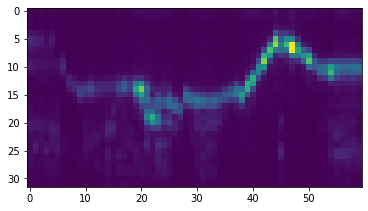

In [369]:
plt.imshow(transformed_img[:,:,0])

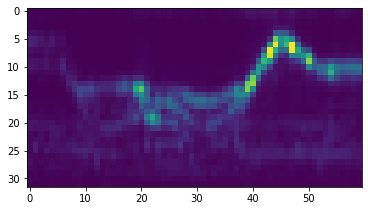

In [370]:
plt.imshow(true_img[:,:,0])

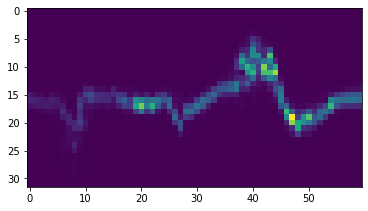

In [373]:
plt.imshow(transformed_img[:,:,1])
#plt.savefig('V3_t_joseph_2.png')

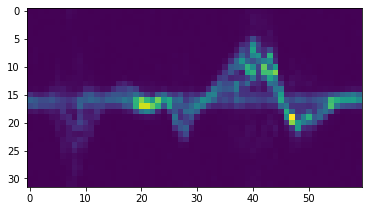

In [374]:
plt.imshow(true_img[:,:,1])
#plt.savefig('V2_t_joseph_2.png')

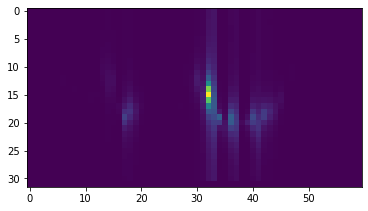

In [268]:
plt.imshow(transformed_img[:,:,2])

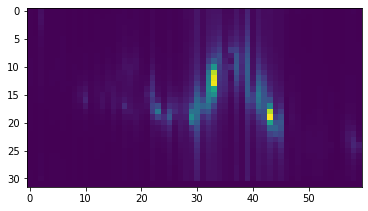

In [211]:
plt.imshow(true_img[:,:,2])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


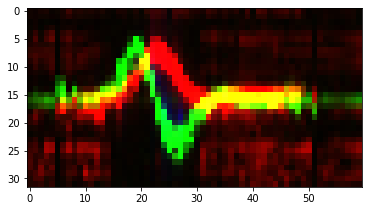

In [24]:
plt.imshow(transformed_img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


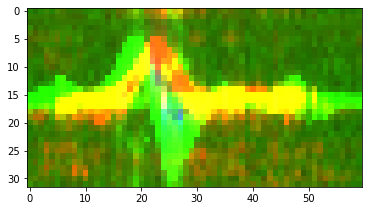

In [25]:
plt.imshow(true_img)